In [8]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_2/NGC-3217_2_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_2/NGC-3217_2_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        40   (2094, 964)   float32   


In [3]:
image_cut = image[67:167, 0:1890]
image_error_cut = image_error[67:167, 0:1890]

Text(0.5, 0, 'wavelength')

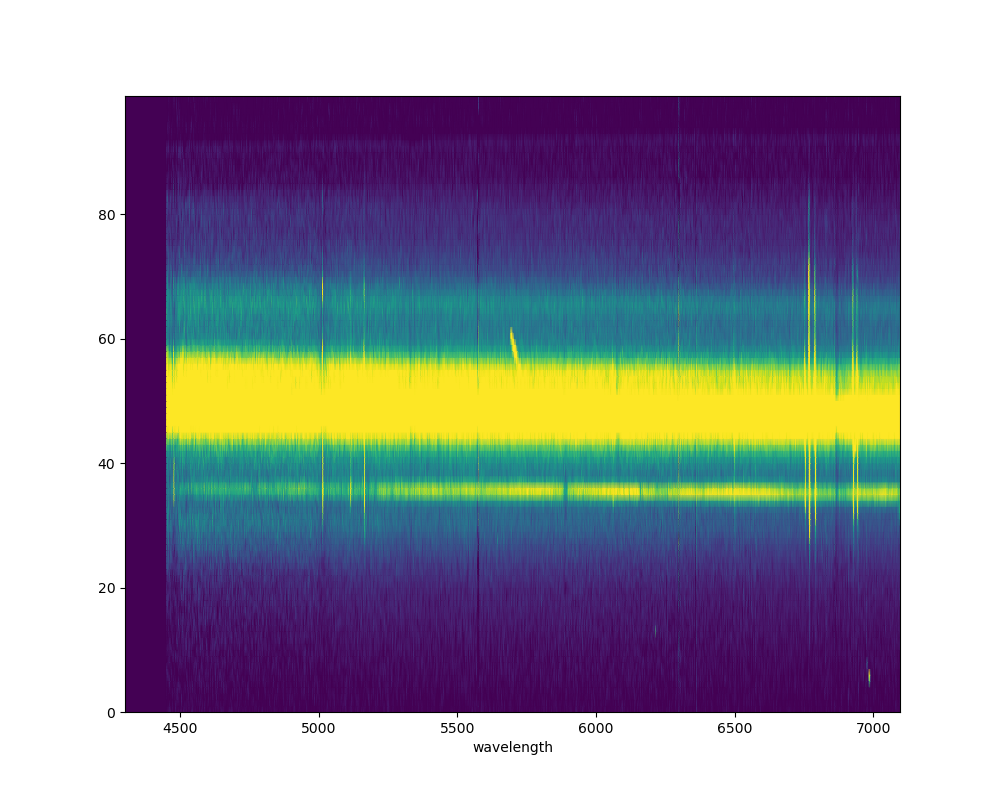

In [9]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [5]:
z = 0.03191
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_2/PSF/Real_seeing_NGC3217_2.txt")
sigmas = seeing / 2.35
print(sigmas)

[0.82805206 0.93317351 0.82656693 0.81685935 0.93037569 0.84425532]


## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_2/NGC-3217_2_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        40   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

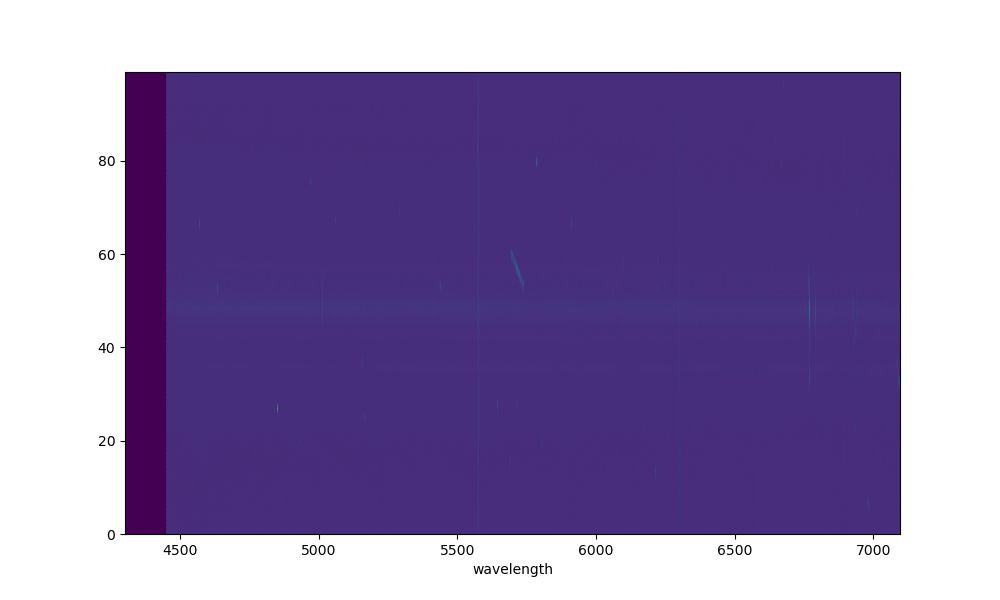

In [7]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_2/NGC-3217_2_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[67:167, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

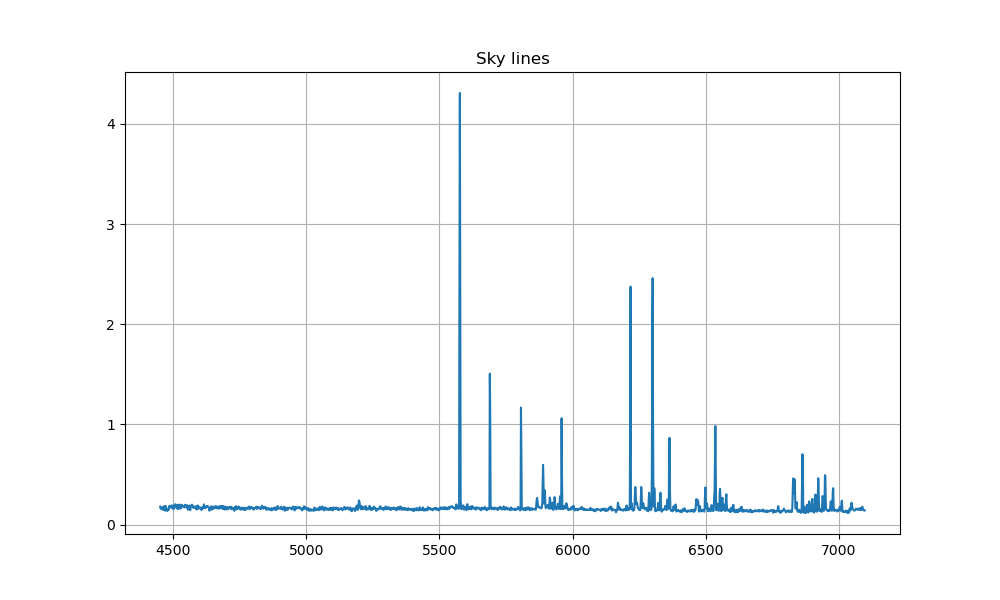

In [8]:
mask_sky = (y > 10)*(y < 20)
mask_wv = wv > 4451
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

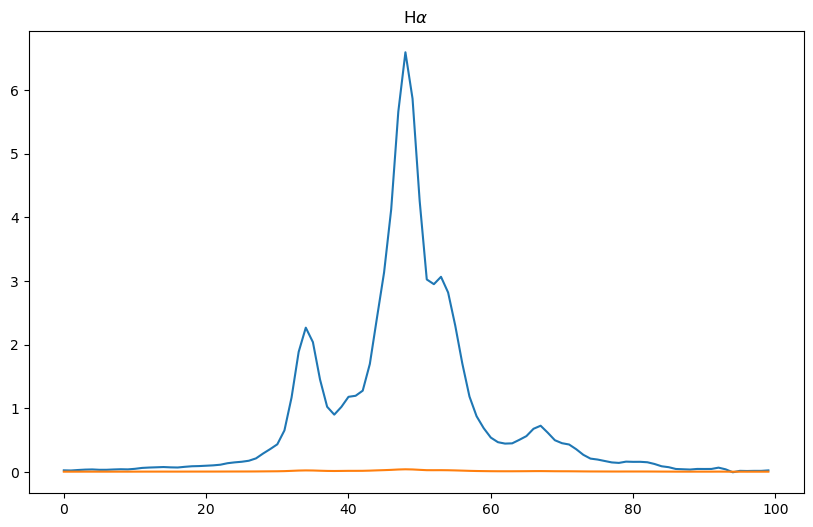

In [6]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_2/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [10]:
n_component = 4

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])#+
        #sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 8)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 8)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (30, 38),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (50, 55),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (65, 75)   
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [11]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1047.3094787149676
differential_evolution step 2: f(x)= 823.9253112880334
differential_evolution step 3: f(x)= 823.9253112880334
differential_evolution step 4: f(x)= 823.9253112880334
differential_evolution step 5: f(x)= 823.9253112880334
differential_evolution step 6: f(x)= 823.9253112880334
differential_evolution step 7: f(x)= 823.9253112880334
differential_evolution step 8: f(x)= 823.9253112880334
differential_evolution step 9: f(x)= 823.9253112880334
differential_evolution step 10: f(x)= 823.9253112880334
differential_evolution step 11: f(x)= 823.9253112880334
differential_evolution step 12: f(x)= 633.4709930728487
differential_evolution step 13: f(x)= 633.4709930728487
differential_evolution step 14: f(x)= 633.4709930728487
differential_evolution step 15: f(x)= 633.4709930728487
differential_evolution step 16: f(x)= 633.4709930728487
differential_evolution step 17: f(x)= 211.95607947524286
differential_evolution step 18: f(x)= 211.9560794752428

Sérsic 1: I_e=0.3399, r_e=3.8676, n=1.3171, x_0=34.0449
Sérsic 2: I_e=0.8079, r_e=8.2262, n=1.3864, x_0=48.0222
Sérsic 3: I_e=1.2003, r_e=1.5350, n=0.1404, x_0=54.1241
Sérsic 4: I_e=0.0194, r_e=49.0467, n=2.1173, x_0=67.1388


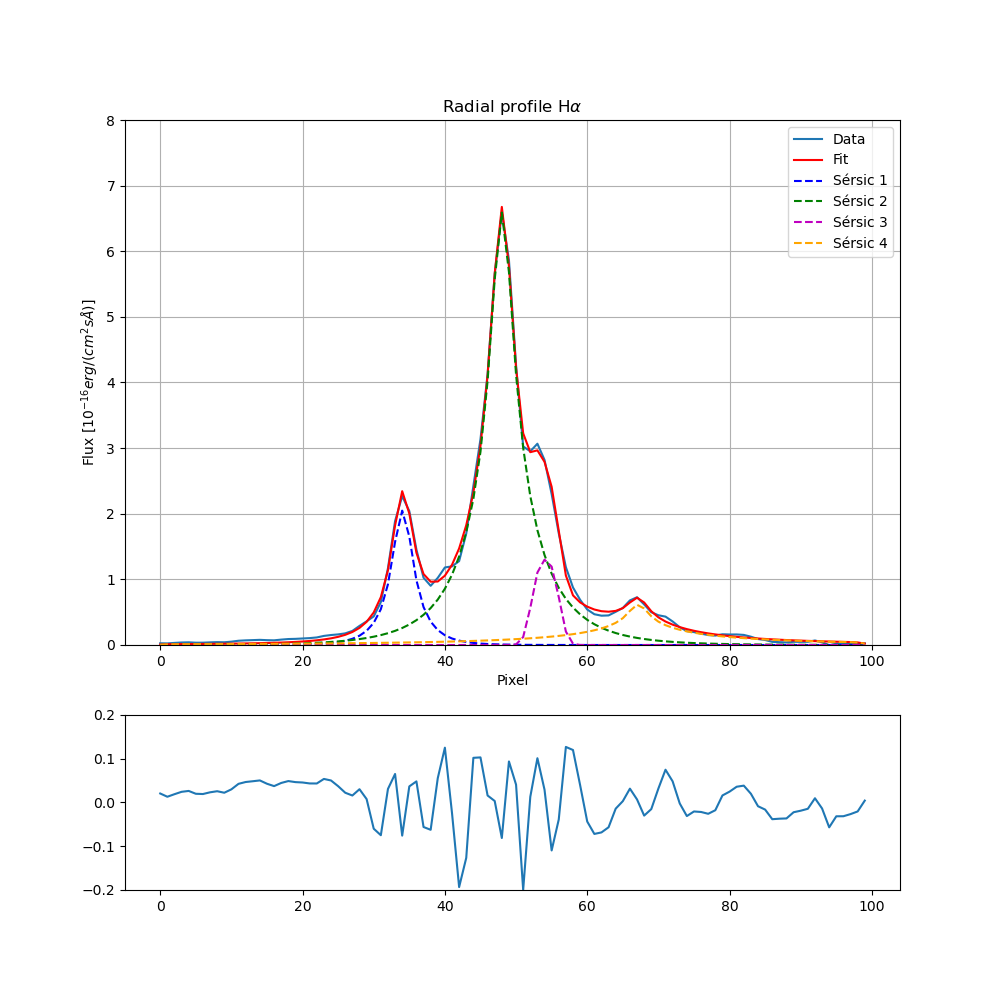

In [12]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha_diff", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [13]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA)#, bounds = bounds_list, maxfev= 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_4612\568277273.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_4612\568277273.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.3798, r_e=3.1140, n=1.2682, x_0=34.0566
Sérsic 2: I_e=0.4419, r_e=12.2571, n=1.8282, x_0=47.8854
Sérsic 3: I_e=0.7651, r_e=1.9739, n=0.5429, x_0=53.8421
Sérsic 4: I_e=0.0075, r_e=72.4043, n=2.7278, x_0=67.2779
[9.50437395e-02 5.24409835e-01 1.99822231e-01 5.45329555e-02
 6.29772774e-02 1.31376902e+00 1.06545945e-01 6.56015113e-02
 1.60649426e-01 2.40728815e-01 1.64845370e-01 1.39679372e-01
 5.79351357e-03 4.91884603e+01 5.29514935e-01 1.58086603e-01]
1.08342220424617


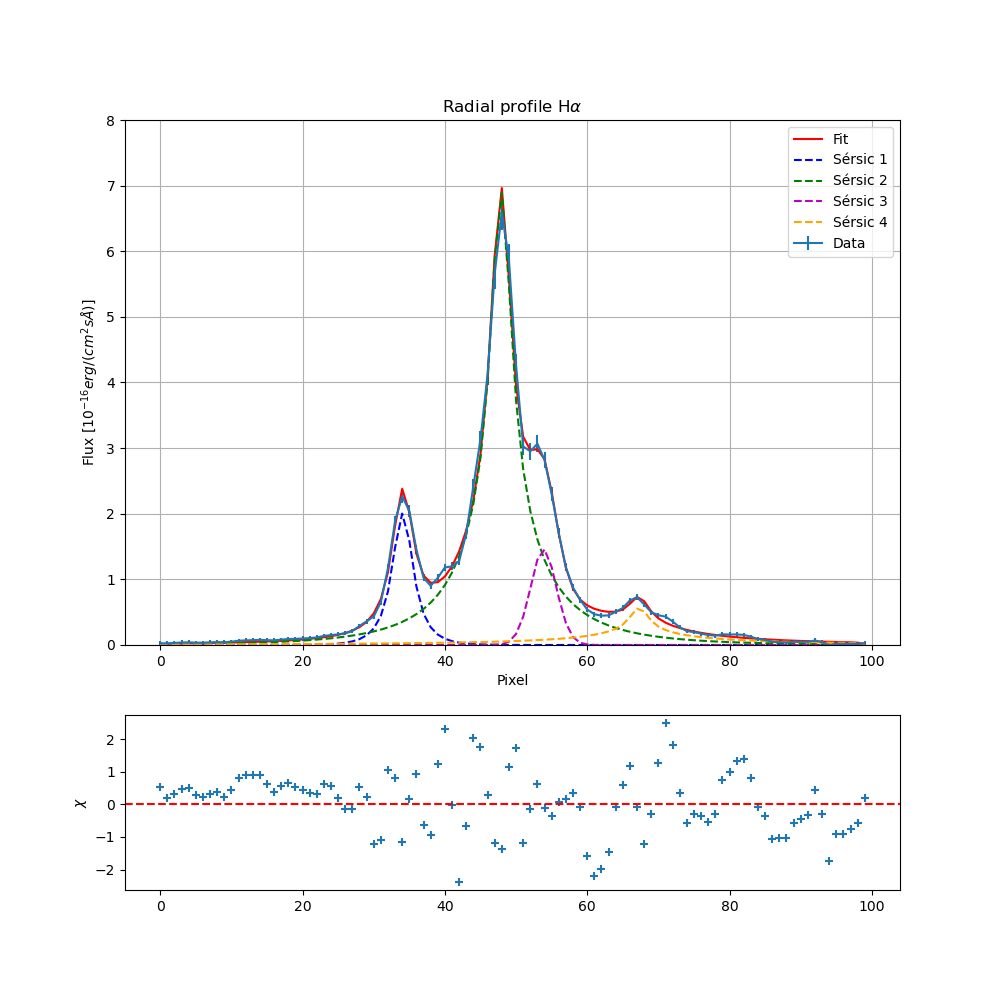

In [14]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [33]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds =  [
    (0, 5),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-(seeing[-1]/2), x_0_HA[0]+(seeing[-1]/2)),   # x_0: posizione da 0 a 100

    (0, 5),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-(seeing[-1]/2), x_0_HA[1]+(seeing[-1]/2)),

    (0, 5),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-(seeing[-1]/2), x_0_HA[2]+(seeing[-1]/2)),

    (0, 5),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-(seeing[-1]/2), x_0_HA[3]+(seeing[-1]/2))
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

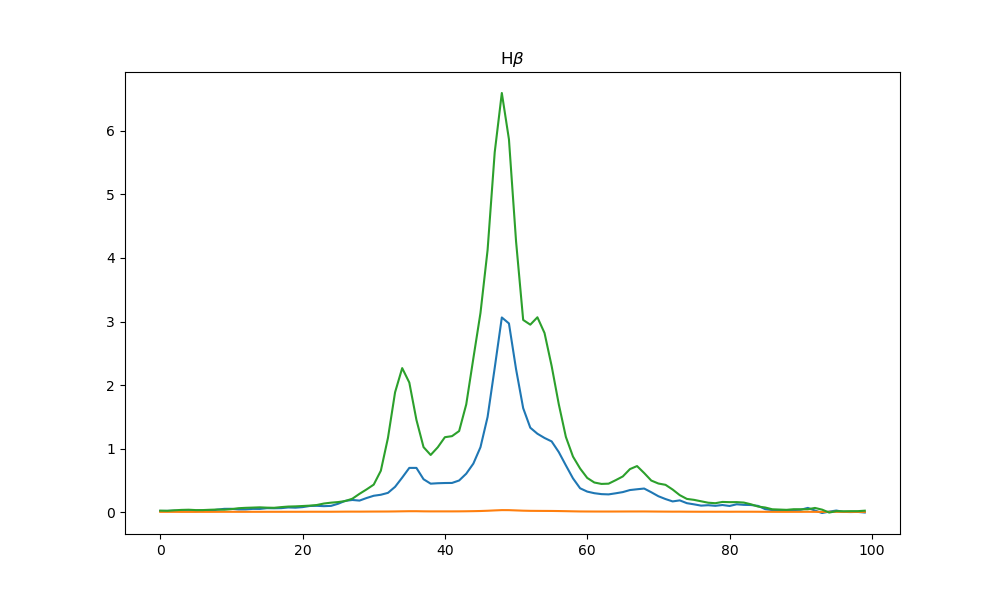

In [16]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))
real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[2])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\beta$')

In [17]:
# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (27, 29),   # x_0: circa la posizione di Halpha

    (0, 5),
    (0, 3),
    (0.1, 10),
    (48, 50),

    (0, 5),
    (0, 3),
    (0.1, 10),
    (51, 53),

    (0, 20),
    (0, 7),
    (0.1, 10),
    (59, 61),

    (0, 20),
    (0, 5),
    (0.1, 10),
    (71, 73),
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 16.189296916463356
differential_evolution step 2: f(x)= 16.189296916463356
differential_evolution step 3: f(x)= 16.189296916463356
differential_evolution step 4: f(x)= 16.189296916463356
differential_evolution step 5: f(x)= 16.189296916463356
differential_evolution step 6: f(x)= 16.189296916463356
differential_evolution step 7: f(x)= 16.189296916463356
differential_evolution step 8: f(x)= 16.189296916463356
differential_evolution step 9: f(x)= 16.189296916463356
differential_evolution step 10: f(x)= 16.189296916463356
differential_evolution step 11: f(x)= 16.189296916463356
differential_evolution step 12: f(x)= 16.189296916463356
differential_evolution step 13: f(x)= 16.189296916463356
differential_evolution step 14: f(x)= 16.189296916463356
differential_evolution step 15: f(x)= 16.078417281445393
differential_evolution step 16: f(x)= 16.078417281445393
differential_evolution step 17: f(x)= 16.078417281445393
differential_evolution step 18: f(x)= 16

Sérsic 1: I_e=0.2616, r_e=10.0000, n=0.1934, x_0=29.0000
Sérsic 2: I_e=0.8233, r_e=3.0000, n=0.9546, x_0=48.0752
Sérsic 3: I_e=0.5789, r_e=3.0000, n=0.1799, x_0=53.0000
Sérsic 4: I_e=0.2966, r_e=7.0000, n=0.2192, x_0=61.0000


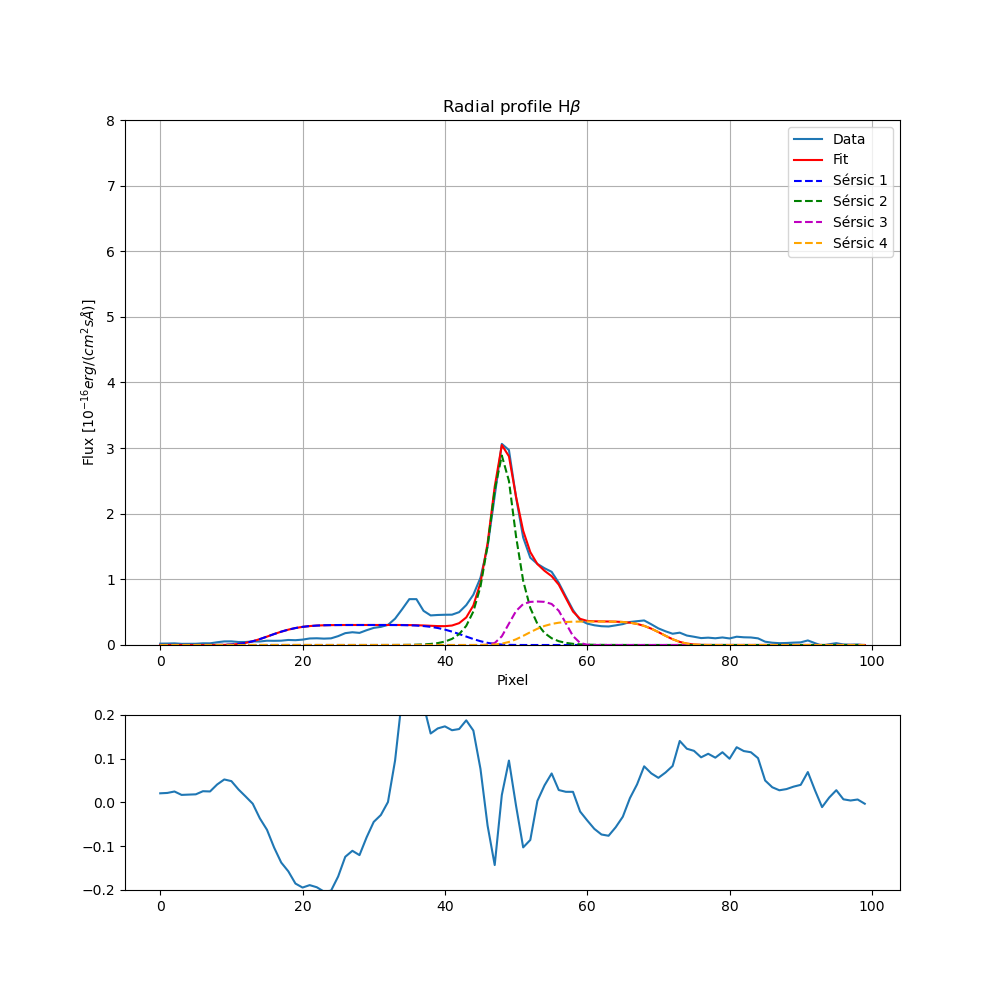

In [18]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [24]:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (27, 29),   # x_0: circa la posizione di Halpha

    (0, 5),
    (0, 10),
    (0.1, 10),
    (48, 50),

    (0, 5),
    (0, 3),
    (0.1, 10),
    (51, 53),

    (0, 20),
    (0, 10),
    (0.1, 10),
    (59, 61),

    (0, 20),
    (0, 7),
    (0.1, 10),
    (71, 73),
]
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB)#, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_4612\568277273.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_4612\568277273.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.0163, r_e=44.5503, n=2.3221, x_0=35.3518
Sérsic 2: I_e=0.4042, r_e=5.4300, n=1.4374, x_0=48.4350
Sérsic 3: I_e=0.3170, r_e=2.8020, n=0.5958, x_0=54.6599
Sérsic 4: I_e=0.0390, r_e=19.5170, n=1.3224, x_0=66.9276
[inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf
 inf inf]
0.3362416082749038


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_4612\541453802.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB)#, bounds = bounds_list, maxfev = 10000)


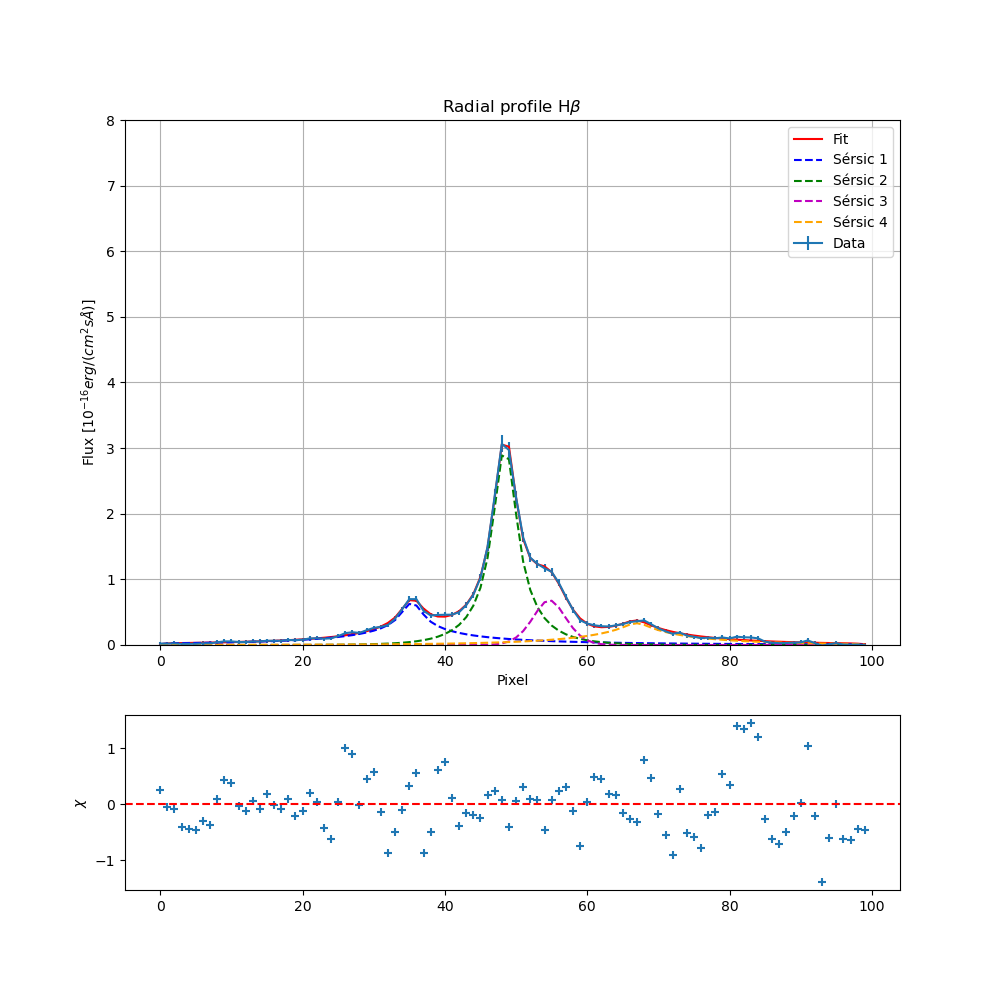

In [25]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

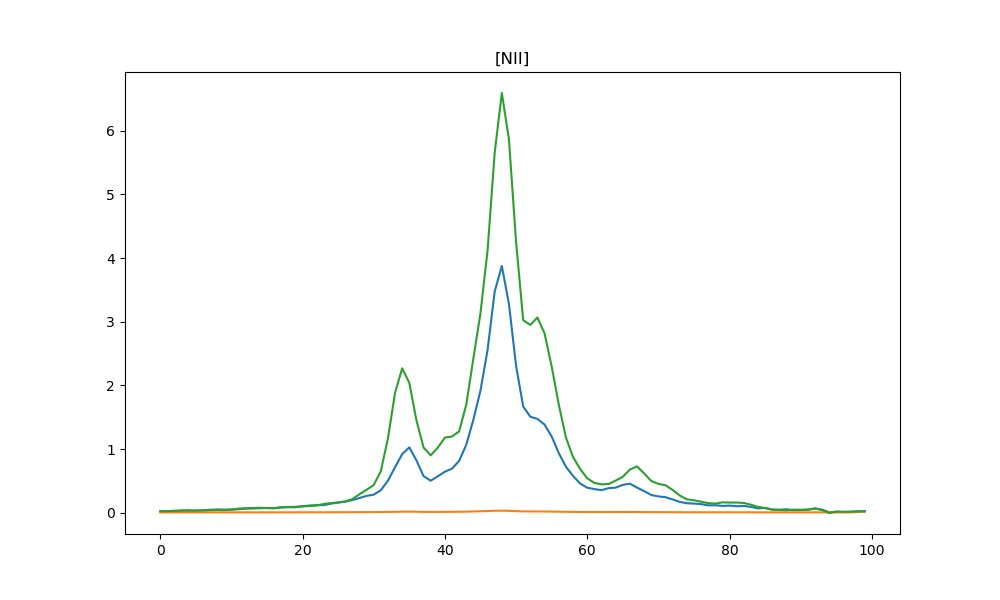

In [42]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))
real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.plot(x_axes, radial_profile_HA)
plt.title(r'[NII]')

In [43]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2548.3037261142445
differential_evolution step 2: f(x)= 1124.0743214438996
differential_evolution step 3: f(x)= 1124.0743214438996
differential_evolution step 4: f(x)= 616.4609845903091
differential_evolution step 5: f(x)= 318.3856614766611
differential_evolution step 6: f(x)= 103.60965355796958
differential_evolution step 7: f(x)= 103.60965355796958
differential_evolution step 8: f(x)= 103.60965355796958
differential_evolution step 9: f(x)= 103.60965355796958
differential_evolution step 10: f(x)= 103.60965355796958
differential_evolution step 11: f(x)= 103.60965355796958
differential_evolution step 12: f(x)= 103.60965355796958
differential_evolution step 13: f(x)= 103.60965355796958
differential_evolution step 14: f(x)= 103.60965355796958
differential_evolution step 15: f(x)= 103.60965355796958
differential_evolution step 16: f(x)= 103.60965355796958
differential_evolution step 17: f(x)= 38.35943793171668
differential_evolution step 18: f(x)= 38.35


KeyboardInterrupt



In [ ]:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [39]:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 5),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-(seeing[-1]/2), x_0_HA[0]+(seeing[-1]/2)),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 20),
    (0.1, 10),
    (x_0_HA[1]-(seeing[-1]/2), x_0_HA[1]+(seeing[-1]/2)),

    (0, 1),
    (0, 5),
    (0.1, 10),
    (x_0_HA[2]-(seeing[-1]/2), x_0_HA[2]+(seeing[-1]/2)),

    (0, 1),
    (40, 60),
    (0.1, 10),
    (x_0_HA[3]-(seeing[-1]/2), x_0_HA[3]+(seeing[-1]/2))
]
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0702, r_e=4.9985, n=1.7661, x_0=34.3829
Sérsic 2: I_e=0.1412, r_e=19.9999, n=2.2425, x_0=47.7924
Sérsic 3: I_e=0.2799, r_e=2.1406, n=0.5554, x_0=54.0239
Sérsic 4: I_e=0.0059, r_e=59.1569, n=2.4188, x_0=66.2859
[4.98449610e-02 2.78364398e+00 5.27918921e-01 7.24555238e-02
 2.98845392e-02 3.71459101e+00 1.49369588e-01 4.98358635e-02
 7.76635082e-02 3.71219176e-01 2.09493918e-01 1.64499226e-01
 5.56935667e-03 5.42533746e+01 6.27106006e-01 2.23640290e-01]
0.6360978019109853


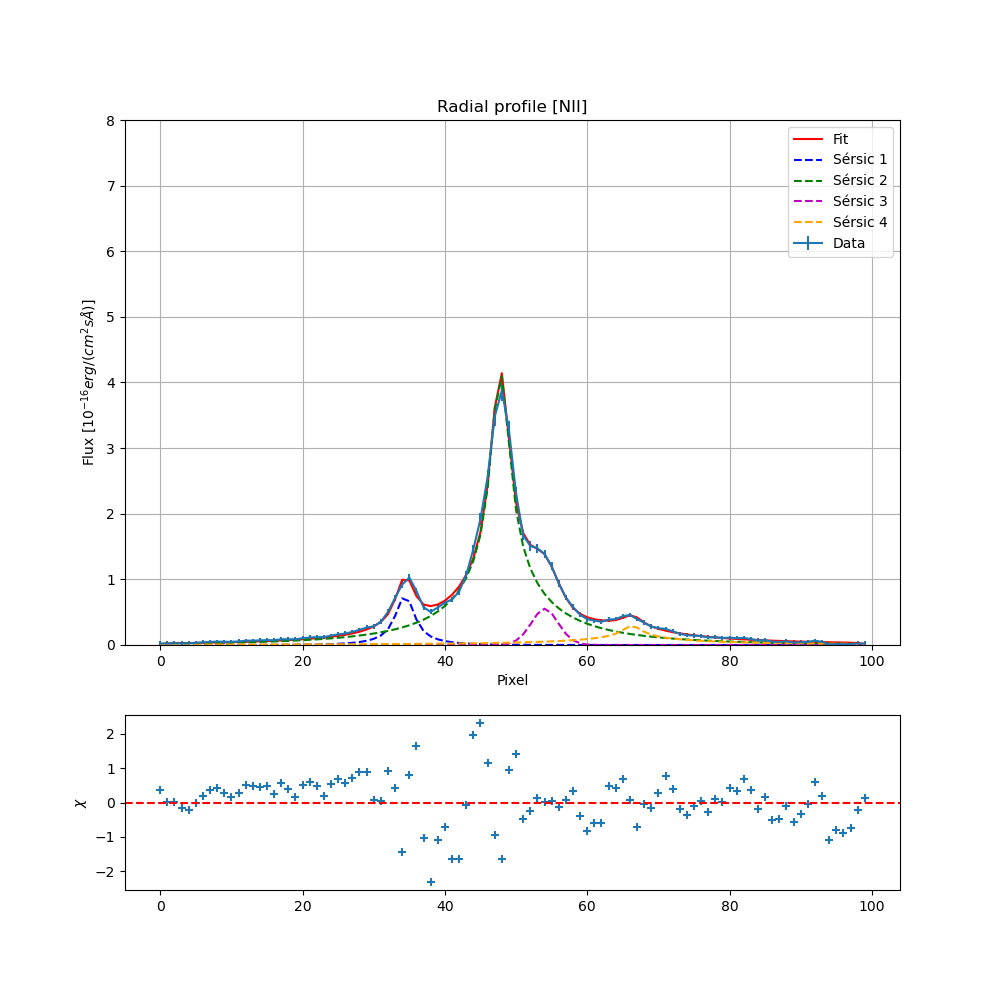

In [40]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

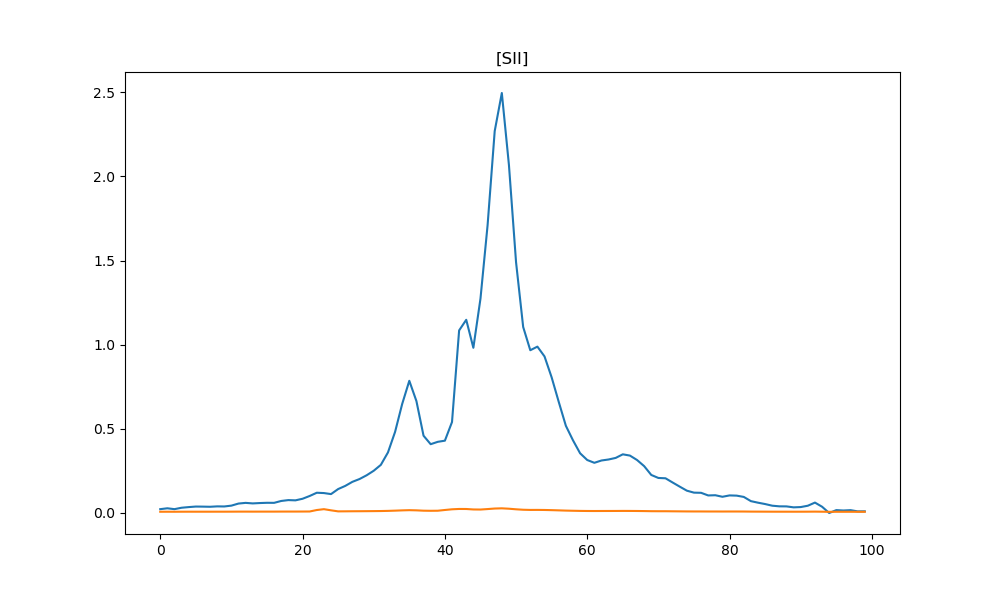

In [41]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))
real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[2])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [44]:
# Bounds:
bounds = [
    (0, 5),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-(seeing[-1]/2), x_0_HA[0]+(seeing[-1]/2)),   # x_0: posizione da 0 a 100

    (0, 5),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-(seeing[-1]/2), x_0_HA[1]+(seeing[-1]/2)),

    (0, 5),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-(seeing[-1]/2), x_0_HA[2]+(seeing[-1]/2)),

    (0, 5),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-(seeing[-1]/2), x_0_HA[3]+(seeing[-1]/2))
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3372.389493811377
differential_evolution step 2: f(x)= 679.1936591455955
differential_evolution step 3: f(x)= 510.55201317211163
differential_evolution step 4: f(x)= 510.55201317211163
differential_evolution step 5: f(x)= 151.90929354386168
differential_evolution step 6: f(x)= 79.9756861028566
differential_evolution step 7: f(x)= 79.9756861028566
differential_evolution step 8: f(x)= 79.9756861028566
differential_evolution step 9: f(x)= 79.9756861028566
differential_evolution step 10: f(x)= 79.9756861028566
differential_evolution step 11: f(x)= 33.355798897078856
differential_evolution step 12: f(x)= 10.936075772639885
differential_evolution step 13: f(x)= 10.936075772639885
differential_evolution step 14: f(x)= 10.936075772639885
differential_evolution step 15: f(x)= 10.936075772639885
differential_evolution step 16: f(x)= 10.936075772639885
differential_evolution step 17: f(x)= 10.936075772639885
differential_evolution step 18: f(x)= 10.93607577263

Sérsic 1: I_e=0.3462, r_e=1.1888, n=0.3253, x_0=34.6386
Sérsic 2: I_e=0.1054, r_e=26.7695, n=2.0032, x_0=47.7517
Sérsic 3: I_e=0.2063, r_e=1.2901, n=0.1000, x_0=54.3941
Sérsic 4: I_e=0.0748, r_e=3.2563, n=0.4146, x_0=66.9803


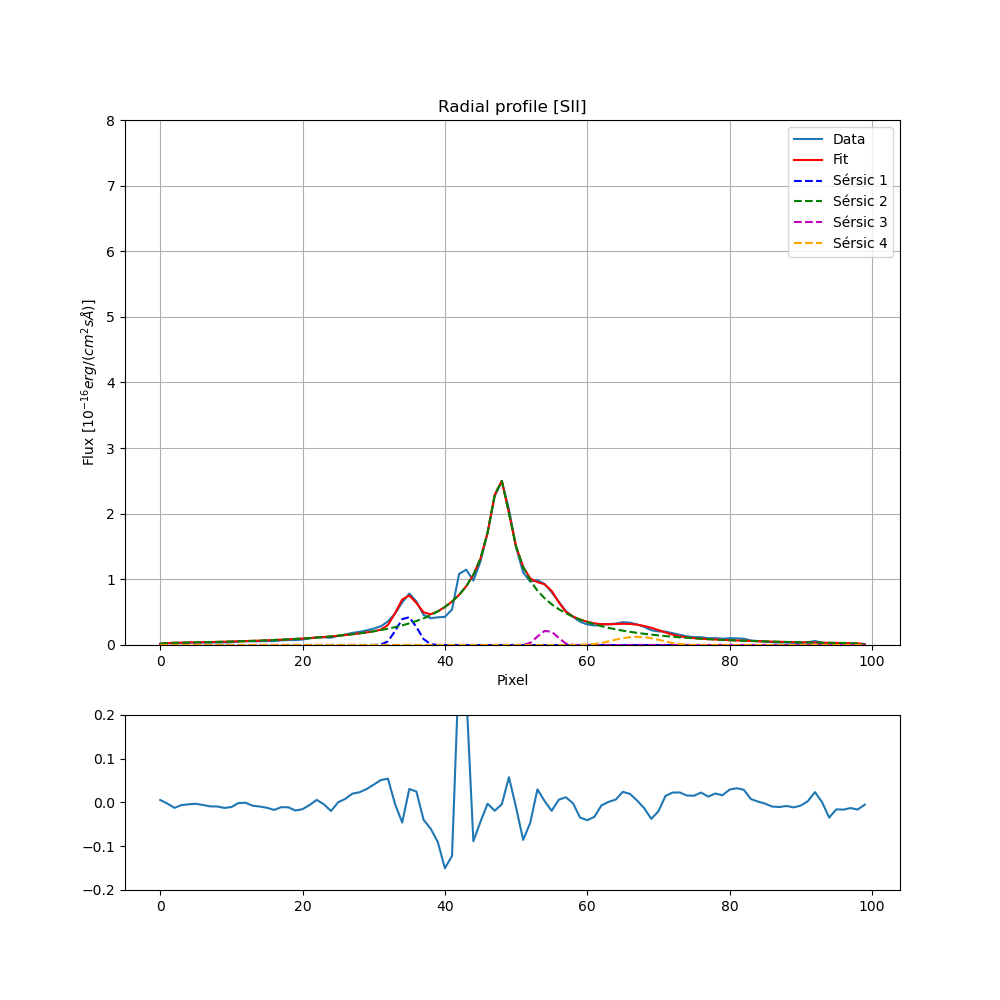

In [45]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [46]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII)#, bounds = bounds_list)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_4612\568277273.py:11: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_4612\568277273.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.2755, r_e=1.3905, n=0.4907, x_0=34.5914
Sérsic 2: I_e=0.0931, r_e=27.7161, n=2.1071, x_0=47.7143
Sérsic 3: I_e=0.0532, r_e=1.7647, n=0.0344, x_0=54.3412
Sérsic 4: I_e=0.0176, r_e=10.2545, n=1.4280, x_0=66.4728
[1.51971781e-01 3.05488738e-01 4.34568434e-01 1.30143761e-01
 1.55204100e-02 3.42602253e+00 1.26076291e-01 7.64069951e-02
 1.86300835e+01 7.96910875e+00 3.68068972e+00 2.75030632e-01
 2.37685104e-02 1.13932231e+01 9.24867301e-01 5.08533510e-01]
1.3378969139757981


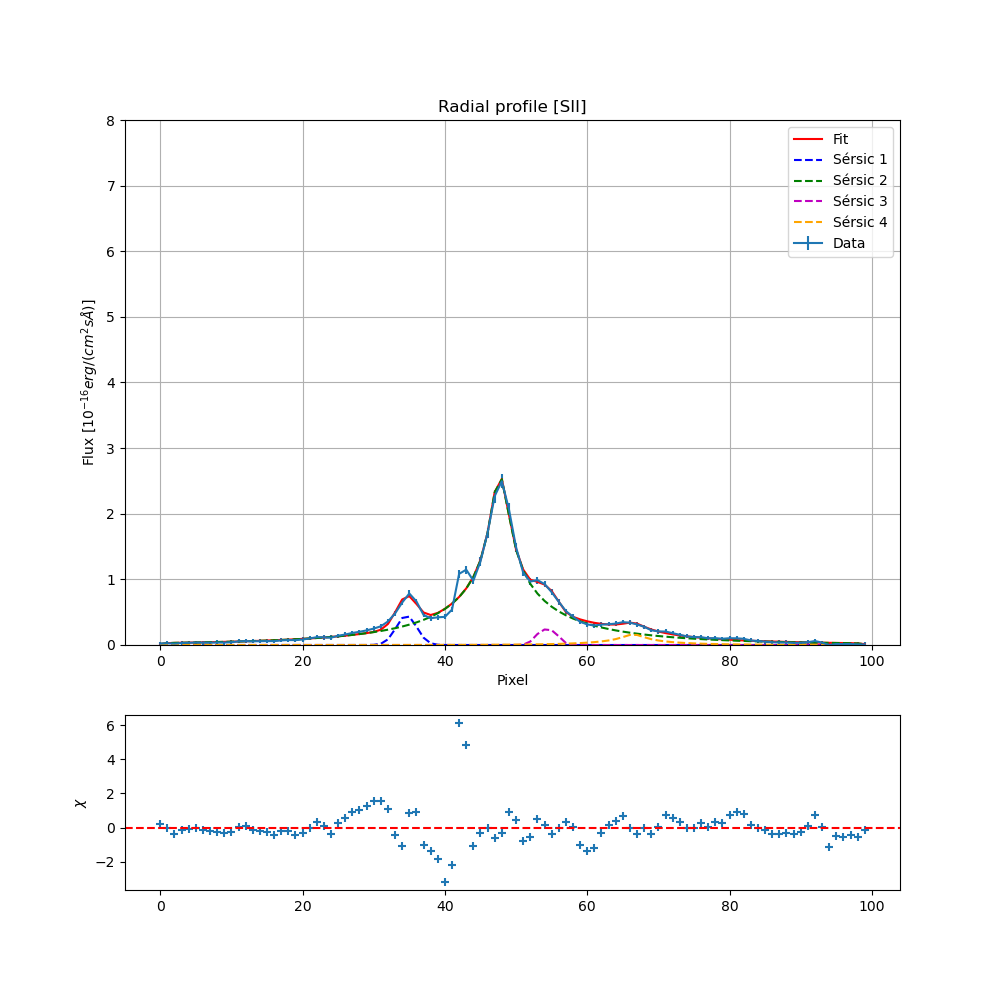

In [47]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

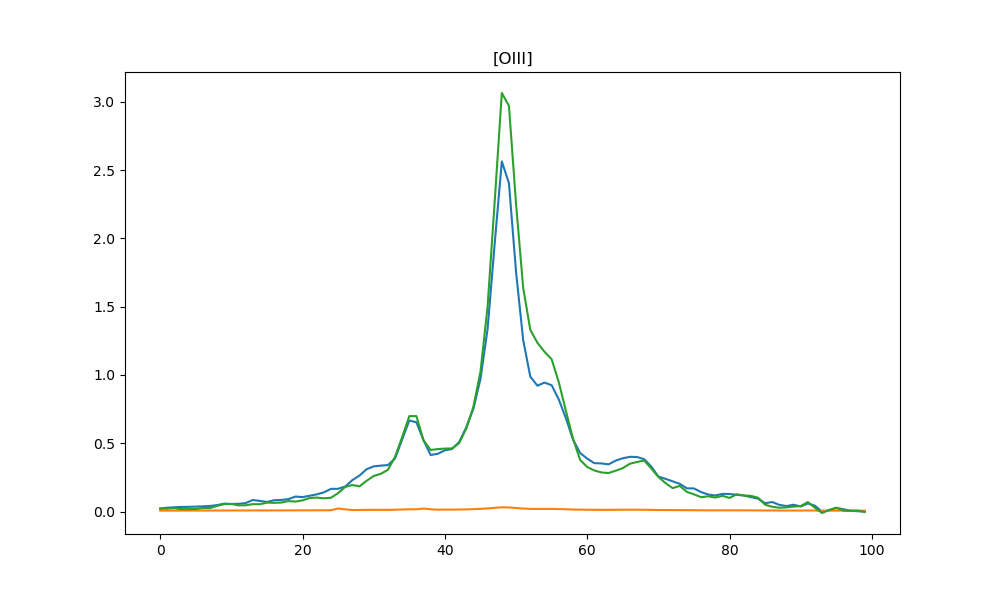

In [48]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))
real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[2])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.plot(x_axes, radial_profile_HB)
plt.title(r'[OIII]')

In [55]:
# Bounds:
bounds =bounds_HA
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 41035.18315948665
differential_evolution step 2: f(x)= 28939.279798602343
differential_evolution step 3: f(x)= 22985.11094409717
differential_evolution step 4: f(x)= 20350.993518043204
differential_evolution step 5: f(x)= 6045.862488441353
differential_evolution step 6: f(x)= 6045.862488441353
differential_evolution step 7: f(x)= 5035.496106949828
differential_evolution step 8: f(x)= 3649.4020890702336
differential_evolution step 9: f(x)= 3649.4020890702336
differential_evolution step 10: f(x)= 3649.4020890702336
differential_evolution step 11: f(x)= 3641.3274617483203
differential_evolution step 12: f(x)= 739.237958632181
differential_evolution step 13: f(x)= 382.2976199375914
differential_evolution step 14: f(x)= 382.2976199375914
differential_evolution step 15: f(x)= 382.2976199375914
differential_evolution step 16: f(x)= 382.2976199375914
differential_evolution step 17: f(x)= 382.2976199375914
differential_evolution step 18: f(x)= 382.2976199375

Sérsic 1: I_e=0.0194, r_e=48.4729, n=2.0830, x_0=35.2776
Sérsic 2: I_e=0.4025, r_e=4.1833, n=1.2661, x_0=48.2700
Sérsic 3: I_e=0.0359, r_e=26.1444, n=1.8539, x_0=55.0000
Sérsic 4: I_e=0.0651, r_e=7.1726, n=0.8625, x_0=67.4561


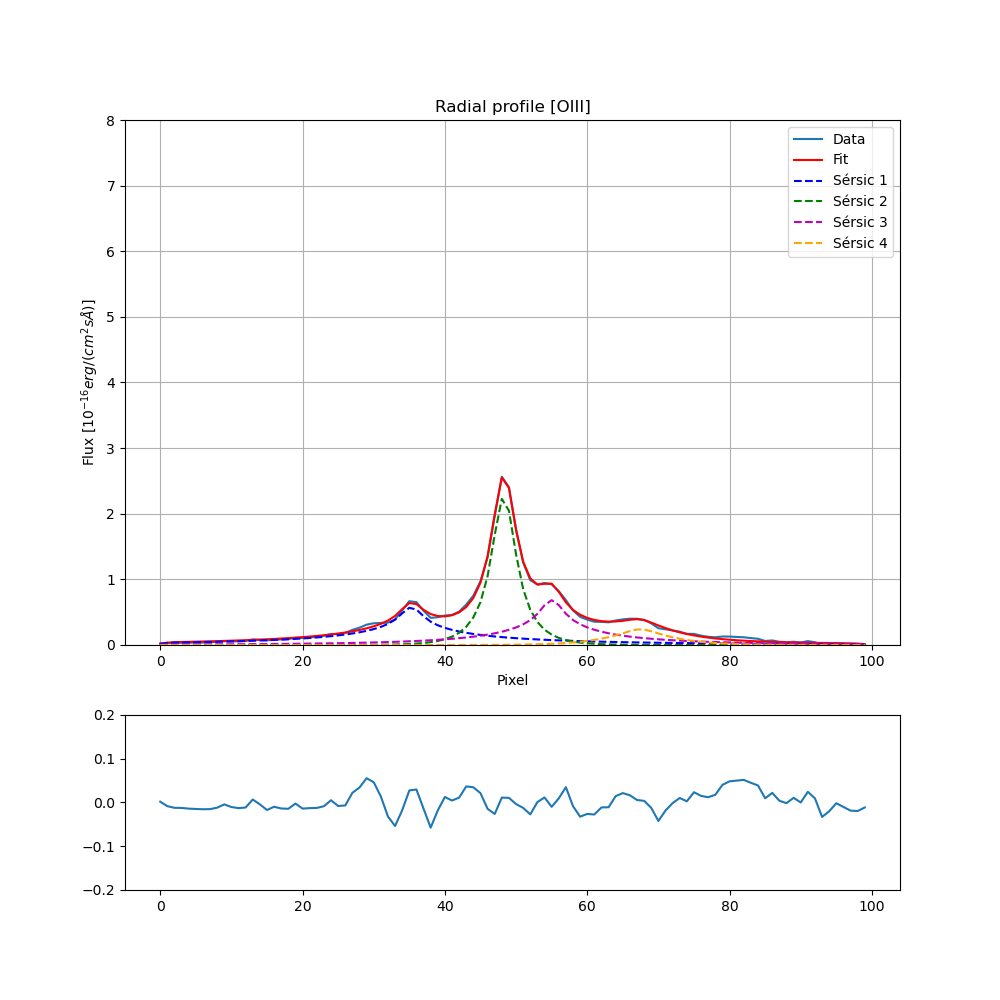

In [56]:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [57]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII) #, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_4612\568277273.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_4612\568277273.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.0315, r_e=35.9381, n=1.7891, x_0=35.2528
Sérsic 2: I_e=0.3770, r_e=4.8950, n=1.3149, x_0=48.2809
Sérsic 3: I_e=0.1450, r_e=3.7615, n=0.9448, x_0=55.1656
Sérsic 4: I_e=0.0566, r_e=17.6186, n=1.1374, x_0=66.3031
[0.0094994  8.44057521 0.2275524  0.04293093 0.04719487 0.4301808
 0.09494443 0.03712425 0.05026817 1.05374845 0.24381297 0.1129913
 0.01100647 2.59561774 0.11944658 0.31590443]
0.316637595646064


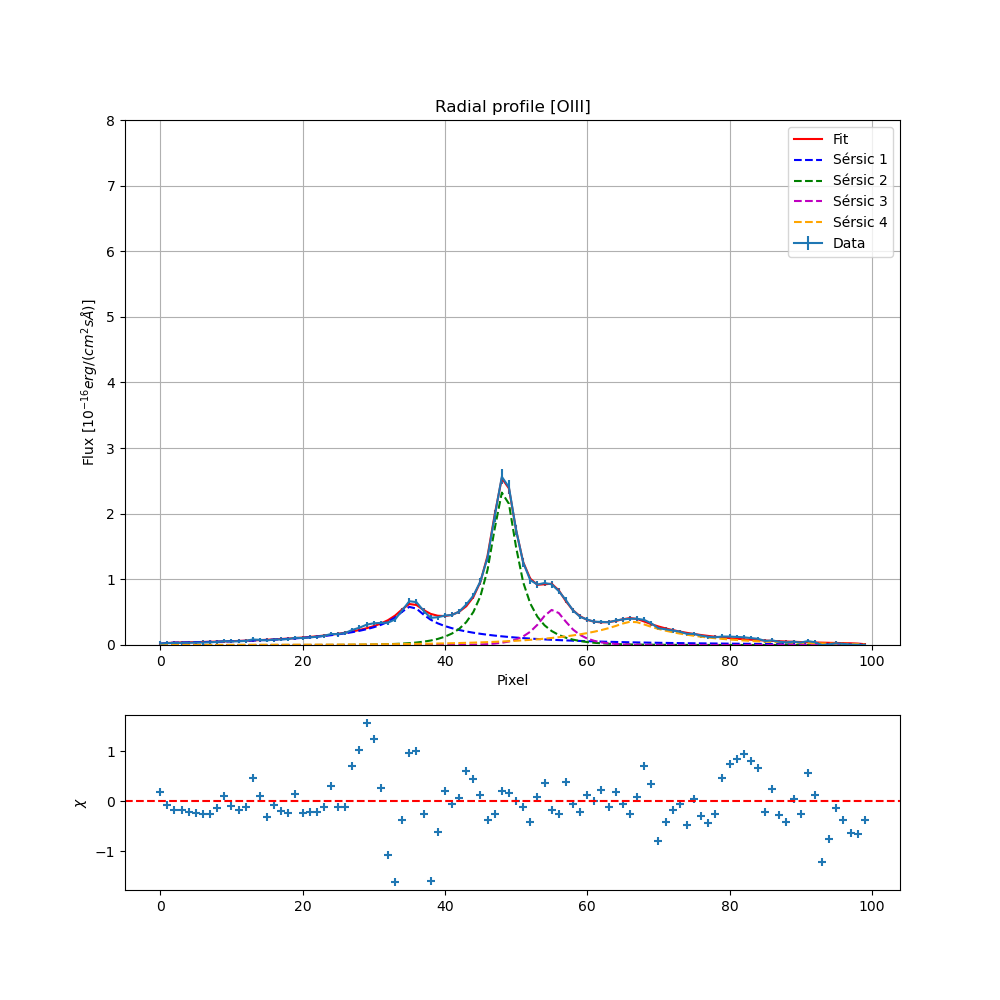

In [58]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [59]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

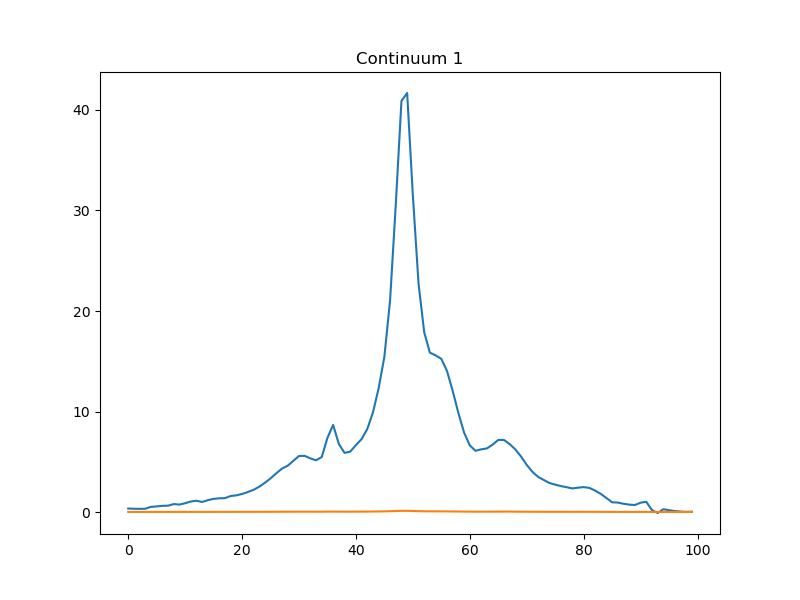

In [60]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))
real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[2])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [61]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 7123.342746530659
differential_evolution step 2: f(x)= 7123.342746530659
differential_evolution step 3: f(x)= 6406.253810631796
differential_evolution step 4: f(x)= 4452.6848435015745
differential_evolution step 5: f(x)= 3619.940953747582
differential_evolution step 6: f(x)= 3619.940953747582
differential_evolution step 7: f(x)= 3013.766612350376
differential_evolution step 8: f(x)= 3013.766612350376
differential_evolution step 9: f(x)= 3013.766612350376
differential_evolution step 10: f(x)= 3013.766612350376
differential_evolution step 11: f(x)= 3013.766612350376
differential_evolution step 12: f(x)= 3013.766612350376
differential_evolution step 13: f(x)= 1191.313622254286
differential_evolution step 14: f(x)= 1191.313622254286
differential_evolution step 15: f(x)= 1163.5832689030271
differential_evolution step 16: f(x)= 1163.5832689030271
differential_evolution step 17: f(x)= 1163.5832689030271
differential_evolution step 18: f(x)= 1163.5832689030

In [64]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

Sérsic 1: I_e=2.2741, r_e=5.8475, n=0.1000, x_0=30.9476
Sérsic 2: I_e=0.6776, r_e=41.5451, n=2.7719, x_0=48.5087
Sérsic 3: I_e=2.6904, r_e=2.5293, n=0.5712, x_0=55.0000
Sérsic 4: I_e=0.6576, r_e=13.9514, n=1.2074, x_0=66.3596


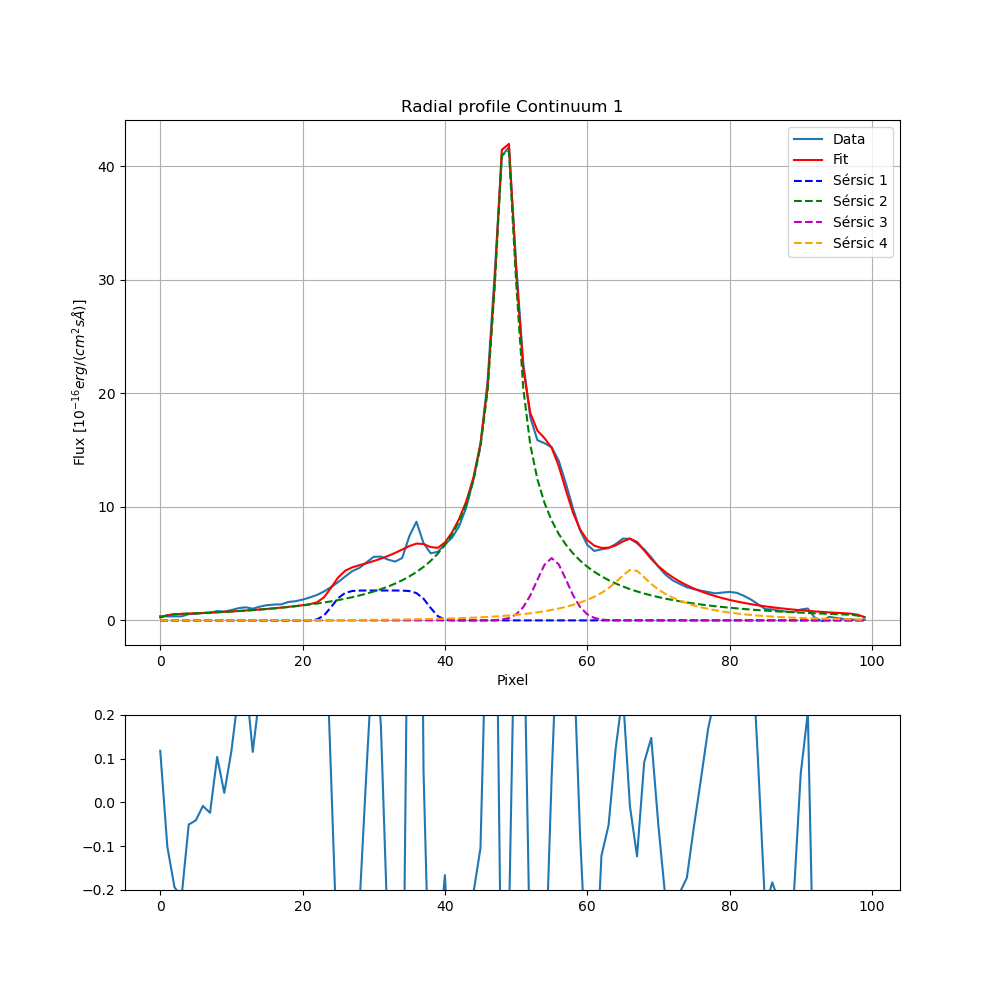

In [65]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [66]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=1.4321, r_e=18.9409, n=0.9115, x_0=34.9654
Sérsic 2: I_e=6.9647, r_e=4.4578, n=1.2415, x_0=48.4419
Sérsic 3: I_e=4.6792, r_e=2.4872, n=0.4060, x_0=55.0000
Sérsic 4: I_e=1.8504, r_e=14.6061, n=0.7439, x_0=65.0000
[0.23983011 1.2917028  0.09031308 1.07970549 3.56048792 1.54818542
 0.39892918 0.19751107 2.11629644 0.75831798 0.346808   0.63690849
 0.26447377 0.67821598 0.08747838 1.1418148 ]
8.360874000508318


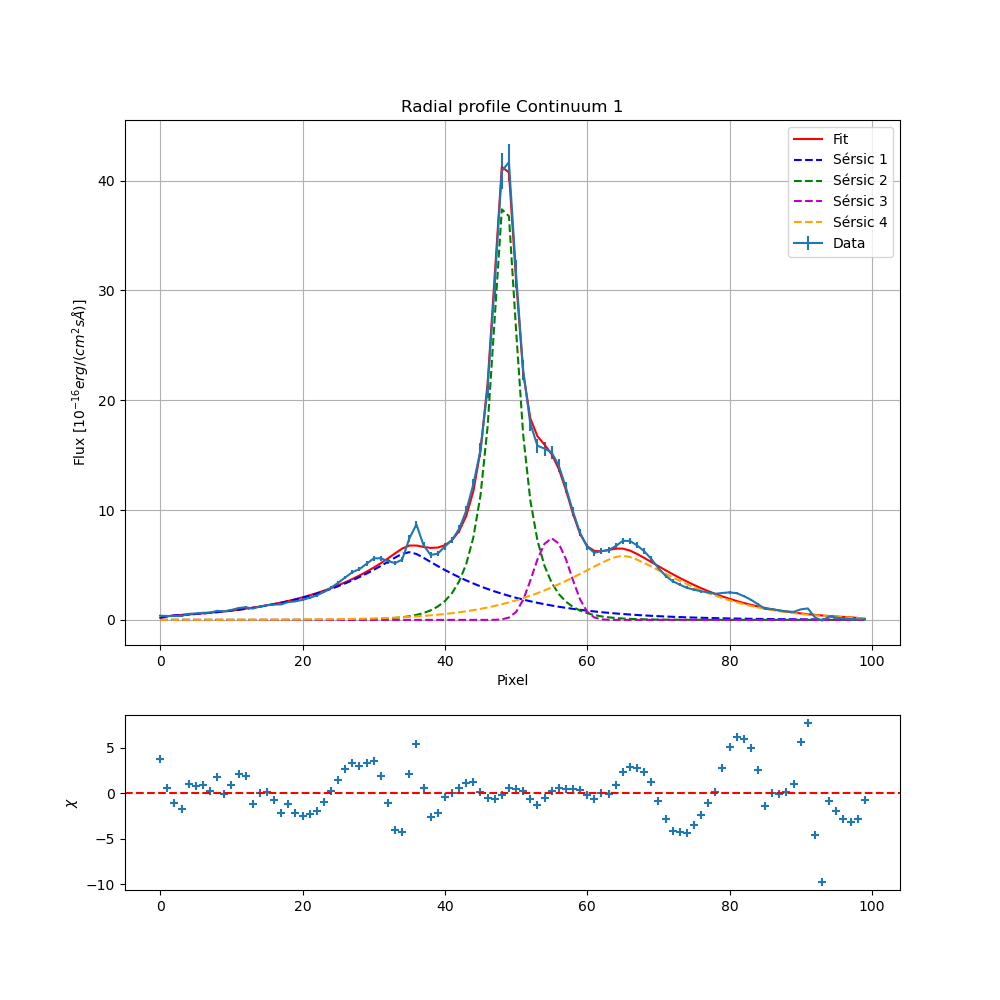

In [67]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

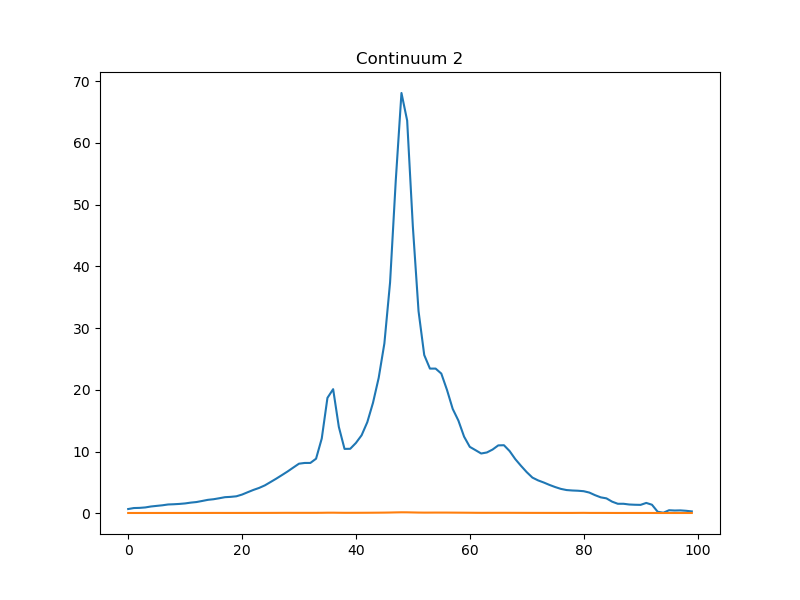

In [68]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))
real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [69]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 11623.106927991945
differential_evolution step 2: f(x)= 11623.106927991945
differential_evolution step 3: f(x)= 7146.897679662442
differential_evolution step 4: f(x)= 2856.546912374427
differential_evolution step 5: f(x)= 2856.546912374427
differential_evolution step 6: f(x)= 2856.546912374427
differential_evolution step 7: f(x)= 2856.546912374427
differential_evolution step 8: f(x)= 2856.546912374427
differential_evolution step 9: f(x)= 1949.5671869514517
differential_evolution step 10: f(x)= 1109.186035322138
differential_evolution step 11: f(x)= 1109.186035322138
differential_evolution step 12: f(x)= 1109.186035322138
differential_evolution step 13: f(x)= 1035.61997367669
differential_evolution step 14: f(x)= 1035.61997367669
differential_evolution step 15: f(x)= 646.8752281436429
differential_evolution step 16: f(x)= 646.8752281436429
differential_evolution step 17: f(x)= 646.8752281436429
differential_evolution step 18: f(x)= 486.95342428784096

Sérsic 1: I_e=2.9078, r_e=0.8423, n=1.9546, x_0=35.5004
Sérsic 2: I_e=10.0000, r_e=2.7455, n=1.2201, x_0=48.1481
Sérsic 3: I_e=4.6272, r_e=24.5505, n=1.0117, x_0=50.0007
Sérsic 4: I_e=2.3000, r_e=1.6568, n=0.1036, x_0=66.4189


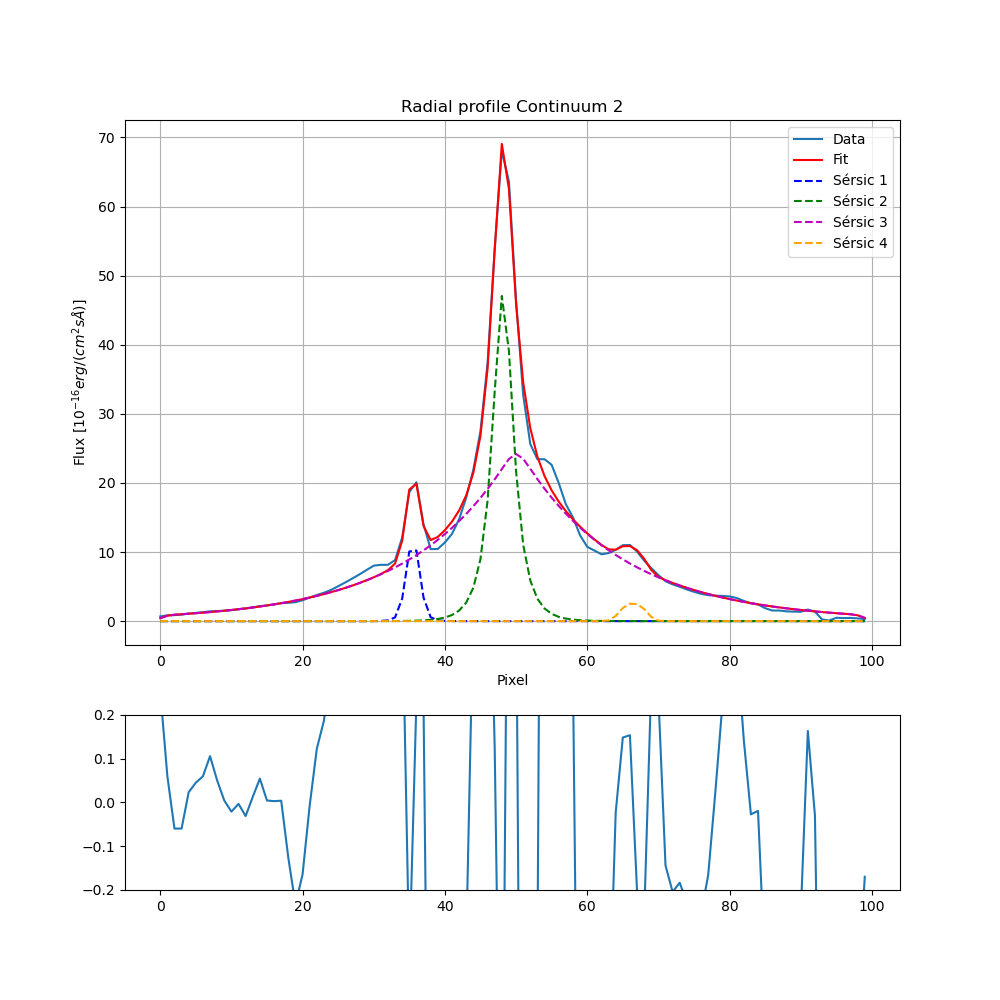

In [70]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigmas[-1],
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [71]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[-1], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigmas[-1], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=9.9998, r_e=0.5711, n=0.6377, x_0=35.4799
Sérsic 2: I_e=10.0000, r_e=3.9242, n=1.2222, x_0=48.4046
Sérsic 3: I_e=5.7588, r_e=22.0983, n=0.6295, x_0=50.0000
Sérsic 4: I_e=2.2688, r_e=1.4013, n=0.1477, x_0=66.2344
[87.637814    0.86032709  8.8378566   0.21925208  6.49691333  1.99156896
  0.5232702   0.19921931  0.4849489   0.75898113  0.08844378  0.31166472
  1.44034405  6.84582033  3.09769607  0.7820291 ]
15.290701885179807


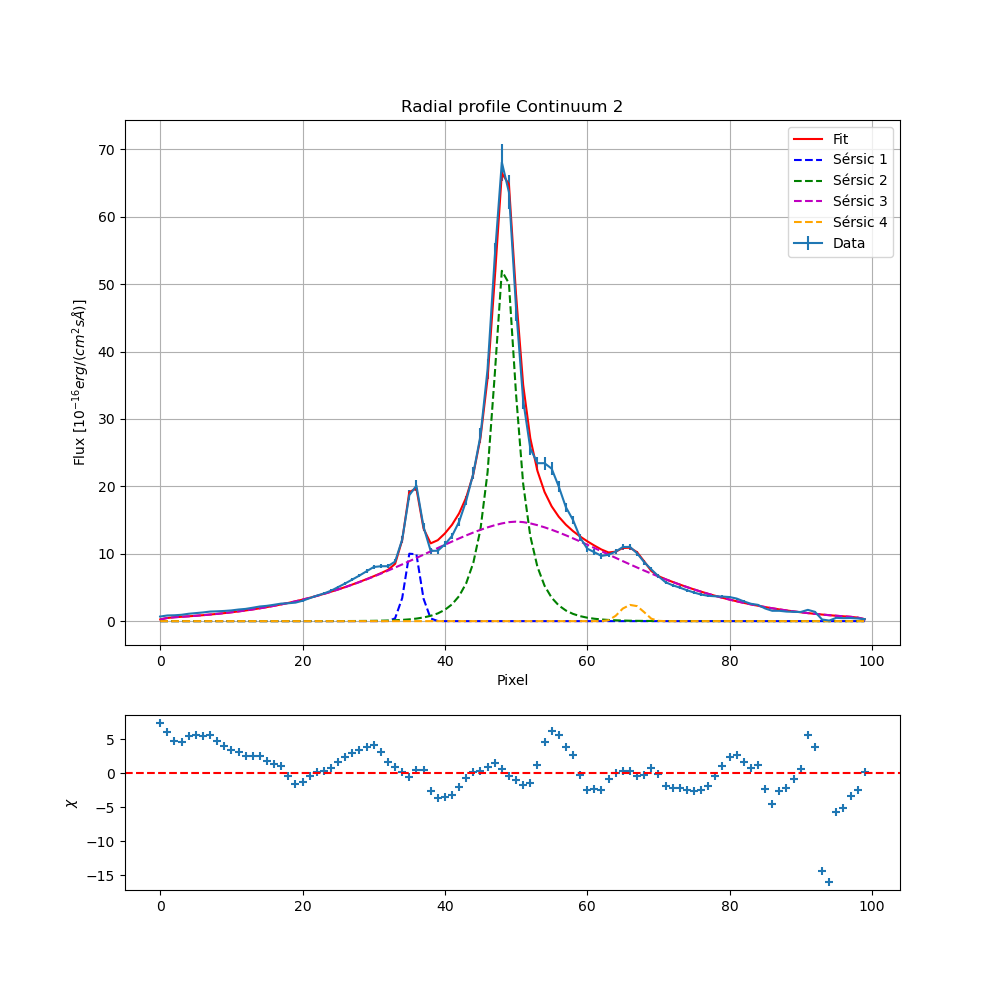

In [72]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

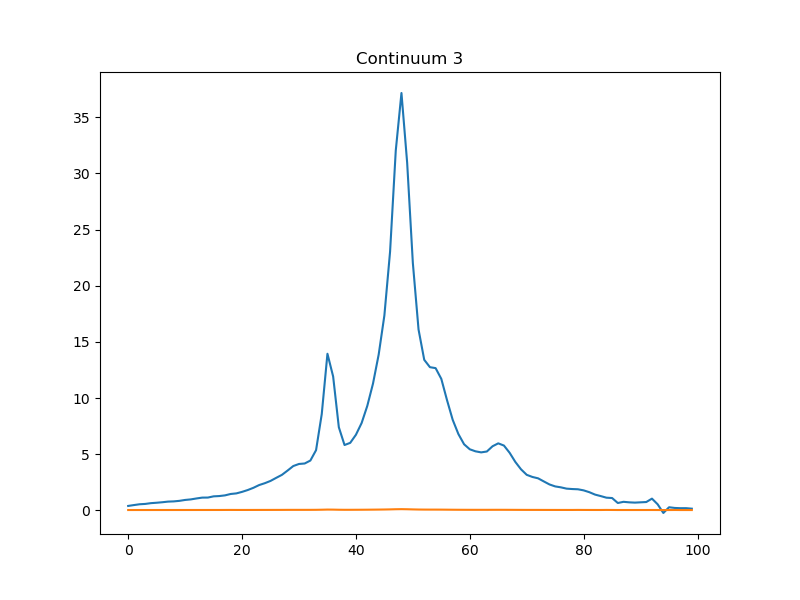

In [73]:
mask_continuum_3 = (wv > 6400)*(wv < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [74]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 8473.802938721768
differential_evolution step 2: f(x)= 4854.564849158121
differential_evolution step 3: f(x)= 3442.79278941798
differential_evolution step 4: f(x)= 3442.79278941798
differential_evolution step 5: f(x)= 3442.79278941798
differential_evolution step 6: f(x)= 3263.748108512001
differential_evolution step 7: f(x)= 2323.254184840954
differential_evolution step 8: f(x)= 1683.5854763982168
differential_evolution step 9: f(x)= 1683.5854763982168
differential_evolution step 10: f(x)= 643.1398150715921
differential_evolution step 11: f(x)= 643.1398150715921
differential_evolution step 12: f(x)= 603.8470252489155
differential_evolution step 13: f(x)= 603.8470252489155
differential_evolution step 14: f(x)= 503.2601775751002
differential_evolution step 15: f(x)= 503.2601775751002
differential_evolution step 16: f(x)= 503.2601775751002
differential_evolution step 17: f(x)= 503.2601775751002
differential_evolution step 18: f(x)= 503.2601775751002
di

Sérsic 1: I_e=1.6005, r_e=1.3202, n=2.0111, x_0=35.1785
Sérsic 2: I_e=0.6270, r_e=49.8673, n=2.6273, x_0=47.9133
Sérsic 3: I_e=0.1820, r_e=4.6937, n=2.4968, x_0=54.7519
Sérsic 4: I_e=0.3425, r_e=8.7683, n=1.3769, x_0=65.7153


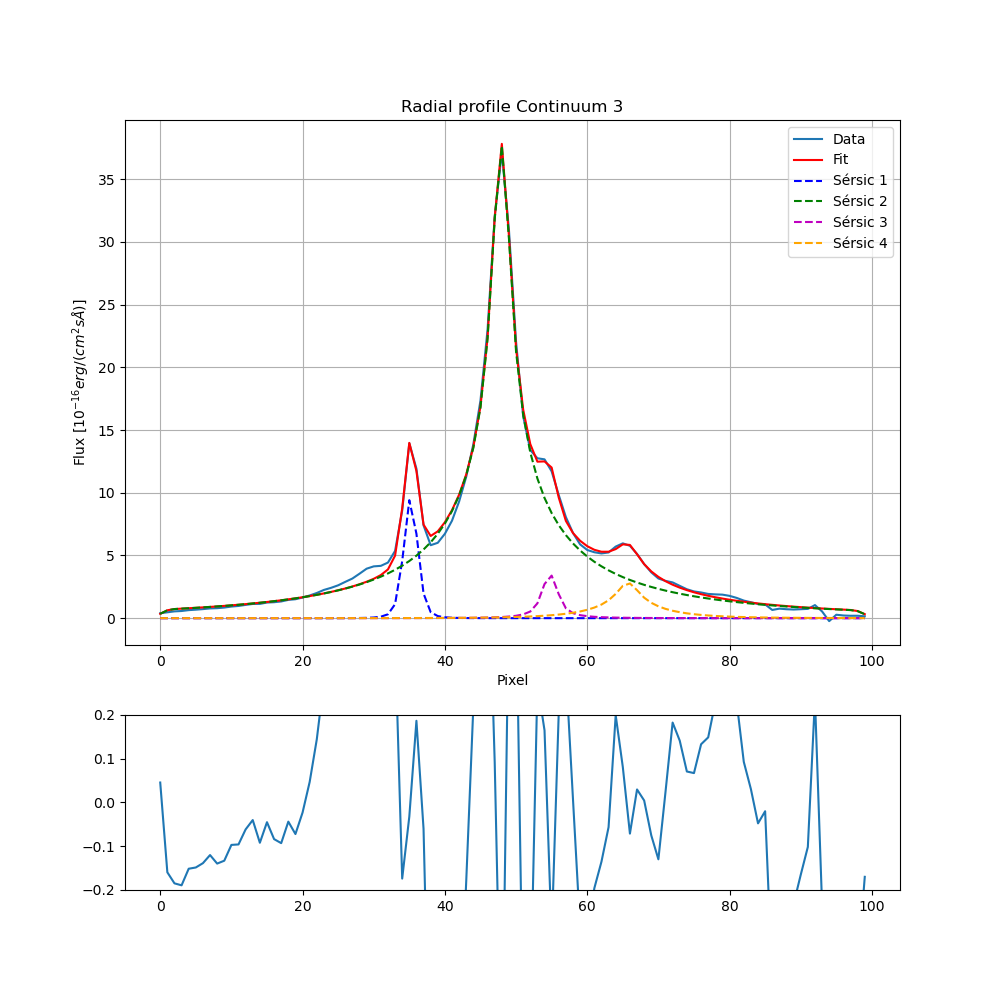

In [75]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [76]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3) #, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_4612\568277273.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_4612\568277273.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.1560, r_e=8.9419, n=3.3877, x_0=35.1785
Sérsic 2: I_e=1.0638, r_e=33.4320, n=2.1918, x_0=47.8549
Sérsic 3: I_e=0.6179, r_e=1.7694, n=1.5656, x_0=54.7370
Sérsic 4: I_e=0.5895, r_e=9.1528, n=0.8896, x_0=65.9159
[1.40010788e+00 5.11420437e+01 1.21281593e+01 9.83641962e-04
 3.31821034e-01 5.48496128e+00 2.73797593e-01 2.33867657e-01
 6.19584877e+00 1.04291781e+01 8.71726243e+00 6.61127162e-01
 3.09157303e-01 3.71673801e+00 3.88373746e-01 1.11832482e+00]
14.099916890215184


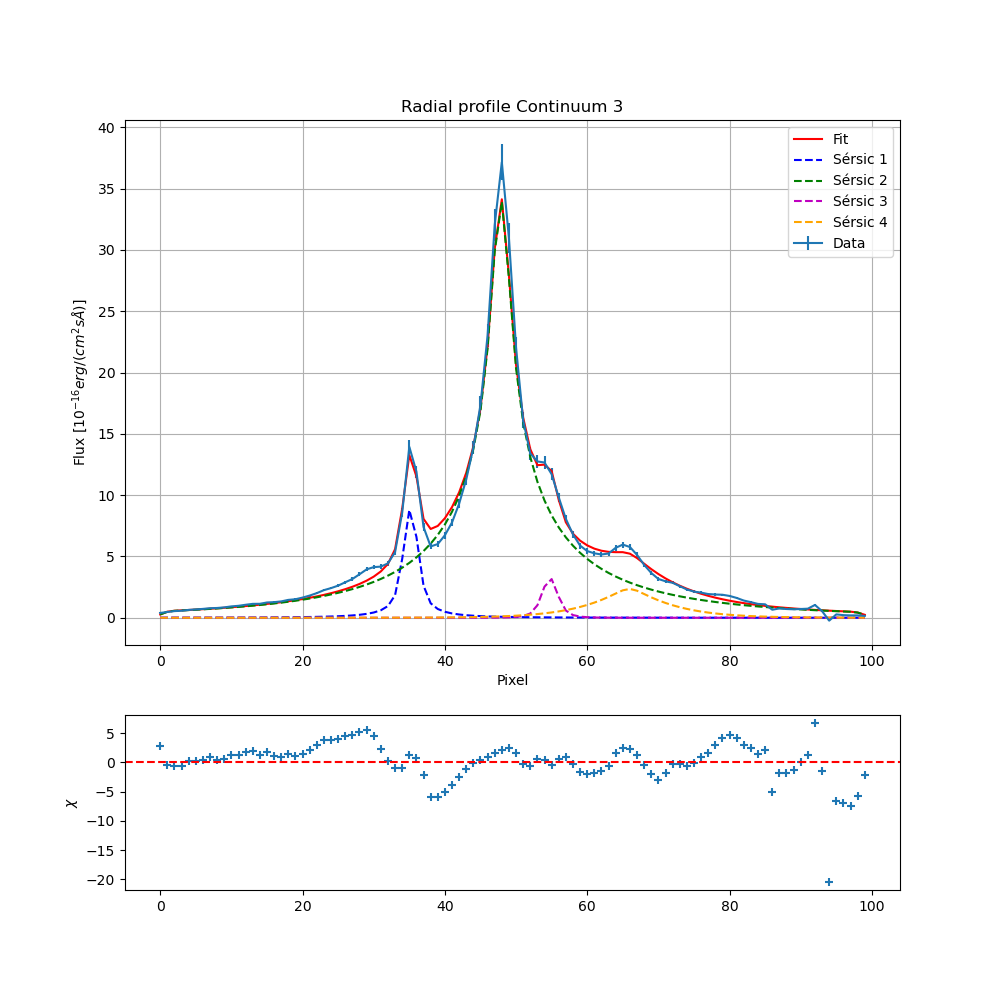

In [77]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [78]:
chi_red = [chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit_continuum.csv", index= False)

## Halpha and continuum

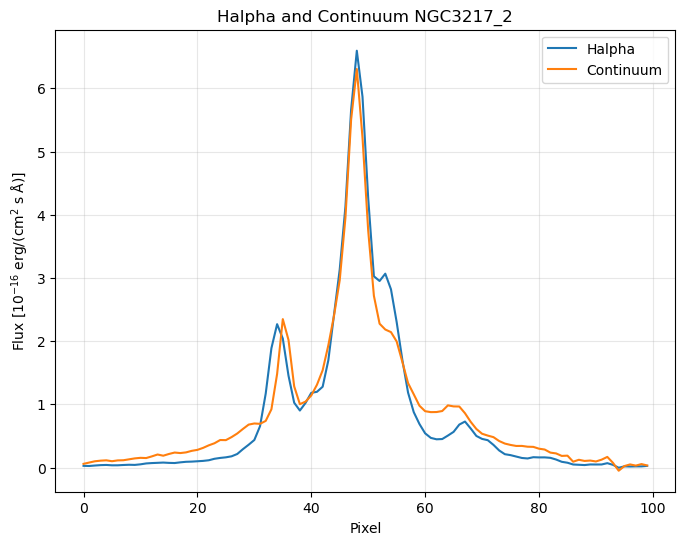

In [7]:
mask_continuum_3 = (wv > 6550)*(wv < 6600)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_HA, label = 'Halpha') 
plt.plot(x_axes, radial_profile_continuum_3, label = 'Continuum')
plt.title(r'Halpha and Continuum NGC3217_2')
plt.legend()
plt.xlabel('Pixel')
plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
plt.grid(alpha = 0.3)
plt.savefig('Halpha_continuum_NGC3217_2')